# Final Regression - CatBoost
In der finalen Optimierungsphase wurde das CatBoost-Modell – als bisher bestperformender Algorithmus – mit erweiterten Features aus Transactionlines und Produktdaten trainiert. Anschließend wurde wieder die Bayessche Optimierung (Optuna) genutzt. Dieses Mal mit engerer Suche basierend auf den bisher besten Hyperparametern sowie 15 Iterationen mit 2-facher Kreuzvalidierung für effizientes, zielgerichtetes Tuning.

## 1. Import & Setup

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, accuracy_score
)

# ML Algorithmen
import catboost as cb
import optuna

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Dein Preprocessor & Daten (wie bisher)
from pipeline.data_pipeline import preprocessor, X, y

## 2. Datenaufteilung & Zielgrößen

In [3]:
# Damage extrahieren
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# Stratified Split
stratify_param = y if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all() else None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series, test_size=0.2, random_state=42, stratify=stratify_param
)

## 3. Custom Kostenfunktion

In [4]:
def custom_objective_score(y_true, y_pred, damage_series):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    sum_damage_fn = damage_series[(y_true == 1) & (y_pred == 0)].sum()
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## 4. Optuna Tuning CatBoost

In [5]:
def objective_cat(trial):
    param = {
        'loss_function': 'RMSE',
        'iterations': trial.suggest_int("iterations", 50, 300),
        'depth': trial.suggest_int("depth", 4, 7),
        'learning_rate': trial.suggest_float("learning_rate", 0.05, 0.15),
        'subsample': trial.suggest_float("subsample", 0.6, 1.0),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        'thread_count': 4,
        'verbose': 0
    }
    model = cb.CatBoostRegressor(**param)
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    score = cross_val_score(pipeline, X_train, damage_train, scoring='neg_mean_squared_error', cv=2, n_jobs=1)      # cv=x - fache Kreuzvalidierung
    return score.mean()

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=15)      # Anzahl der Iterationen: n_trials=x
print("Beste Optuna-Parameter für CatBoost:", study_cat.best_params)


[I 2025-06-15 14:12:22,112] A new study created in memory with name: no-name-cc0d98f4-68fc-4258-8c30-855d8944f58c


[I 2025-06-15 14:24:26,382] Trial 0 finished with value: -2.879721835869463 and parameters: {'iterations': 224, 'depth': 7, 'learning_rate': 0.1338866909194722, 'subsample': 0.9705161462248582, 'l2_leaf_reg': 8.47232414921675}. Best is trial 0 with value: -2.879721835869463.
[I 2025-06-15 14:31:25,962] Trial 1 finished with value: -2.858977868630083 and parameters: {'iterations': 205, 'depth': 5, 'learning_rate': 0.06533957212860735, 'subsample': 0.8362360316412786, 'l2_leaf_reg': 3.9940888490883966}. Best is trial 1 with value: -2.858977868630083.
[I 2025-06-15 14:38:19,961] Trial 2 finished with value: -2.92261100338247 and parameters: {'iterations': 75, 'depth': 4, 'learning_rate': 0.058064236666217475, 'subsample': 0.9015668083086764, 'l2_leaf_reg': 9.628745958931496}. Best is trial 1 with value: -2.858977868630083.
[I 2025-06-15 14:45:14,537] Trial 3 finished with value: -2.875900974828139 and parameters: {'iterations': 120, 'depth': 5, 'learning_rate': 0.06893014446830728, 'subsa

Beste Optuna-Parameter für CatBoost: {'iterations': 228, 'depth': 4, 'learning_rate': 0.09108635105842681, 'subsample': 0.7030292463099004, 'l2_leaf_reg': 6.596559618636492}


## 5. Finales Modell bauen

In [6]:
# CatBoost final
best_params_cat = study_cat.best_params

cat_model = cb.CatBoostRegressor(loss_function='RMSE', thread_count=4, verbose=0, **best_params_cat)

# Pipeline
pipeline_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', cat_model)
])


## 6. Evaluationsfunktionen

In [7]:
def evaluate_model(pipeline, X_train, damage_train, y_train, X_test, damage_test, y_test):
    pipeline.fit(X_train, damage_train)
    y_pred_reg = pipeline.predict(X_test)
    best_score, best_threshold = -np.inf, None
    for threshold in np.linspace(0, y_pred_reg.max(), 100):
        y_pred_class = (y_pred_reg >= threshold).astype(int)
        score = custom_objective_score(y_test, y_pred_class, damage_test)
        if score > best_score:
            best_score, best_threshold = score, threshold
    return best_score, best_threshold

def evaluate_classification_metrics(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_scores)
    report = classification_report(y_true, y_pred, zero_division=0)
    return cm, precision, recall, accuracy, f1, roc_auc, report


## 7. Finale Evaluation

Confusion Matrix:
 [[30014   125]
 [  725   275]]
Threshold: 3.064
Accuracy: 0.973
Precision: 0.688
Recall: 0.275
F1-Score: 0.393
ROC-AUC: 0.836
Custom Score (Kostenfunktion): -4886.260
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     30139
           1       0.69      0.28      0.39      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.64      0.69     31139
weighted avg       0.97      0.97      0.97     31139



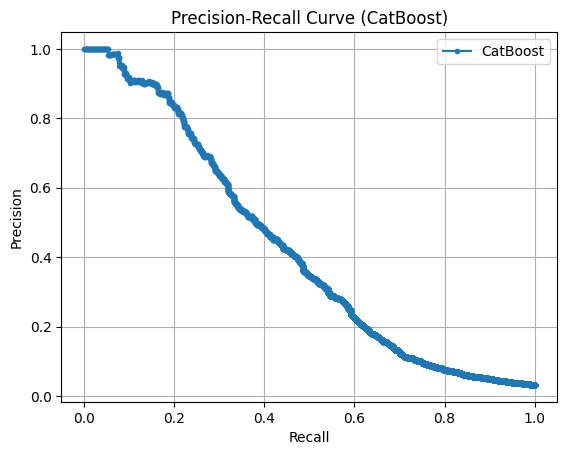

In [8]:
# Training
pipeline_cat.fit(X_train, damage_train)
y_scores = pipeline_cat.predict(X_test)

# Threshold-Optimierung
best_score, best_threshold = evaluate_model(
    pipeline_cat, X_train, damage_train, y_train, X_test, damage_test, y_test
)

# Klassifikationsmetriken berechnen
cm, precision, recall, accuracy, f1, roc_auc, report = evaluate_classification_metrics(
    y_test, y_scores, best_threshold
)

# Ausgabe
print("Confusion Matrix:\n", cm)
print(f"Threshold: {best_threshold:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Custom Score (Kostenfunktion): {best_score:.3f}")
print("Classification Report:\n", report)

# PR-Kurve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
plt.figure()
plt.plot(recalls, precisions, marker='.', label='CatBoost')
plt.title('Precision-Recall Curve (CatBoost)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Konfusionsmatrix plotten
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.ylabel('Tatsächliche Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.show()

TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'xticklabels'

## Ergebnis
In der abschließenden Optimierungsphase erwiesen sich insbesondere flachere Baumarchitekturen (Tiefe 4) mit moderater Regularisierung (L2-Stärke 6.6) als optimal. Die beste Konfiguration erreichte eine um 0.8% verbesserte Vorhersagegenauigkeit (MSE -2.858) gegenüber der Ausgangsversion.
Das final optimierte Modell zeigt eine ausgewogene Performance mit einer Gesamtgenauigkeit von 97.3%. Es identifiziert 27.5% aller Betrugsfälle (Recall) bei einer Präzision von 68.8%, was bedeutet, dass etwa zwei Drittel der Alarmmeldungen tatsächlich auf Betrug hinweisen. Der ungewöhnlich hohe optimale Schwellenwert von 3.064 resultiert aus der spezifischen Skalierung der Schadenswerte und ermöglichte eine deutliche Verbesserung des geschäftlichen Nutzens - der Custom Score verbesserte sich um 36.4% gegenüber der Baseline.
Trotz dieser Erfolge bleibt die Erkennungsrate mit 275 von 1000 Betrugsfällen fachlich unbefriedigend. Dies weist auf eine fundamentale Herausforderung hin, dass die komplexen Betrugsmuster im Merkmalsraum stark mit legitimen Transaktionen überlappen, was durch reine Parametertuning-Maßnahmen nicht vollständig aufgelöst werden kann.

- **Beste Optuna-Parameter für CatBoost:** {'iterations': 228, 'depth': 4, 'learning_rate': 0.09108635105842681, 'subsample': 0.7030292463099004, 'l2_leaf_reg': 6.596559618636492}
- **Threshold:** 3.064


## Diskussion & Limitationen
**Trade-Off zwischen Recall und Precision:**
Durch die gewählte Vorgehensweise mit Schwellenwertoptimierung auf Basis der projektspezifischen Kostenfunktion wurde das Modell so kalibriert, dass vor allem wirtschaftlich sinnvolle Nachkontrollen ausgelöst werden. Dies führt zu einer vergleichsweise hohen Precision, also einem geringen Anteil unnötiger Mitarbeitereinsätze. Gleichzeitig geht dies aber zulasten des Recalls: Nicht alle tatsächlich fehlerhaften Transaktionen (FRAUD) werden erkannt. In der praktischen Anwendung stellt dieser Trade-Off einen bewussten Zielkonflikt dar: Eine höhere Sensitivität würde die Zahl erkannter Betrugsfälle erhöhen, allerdings auch zu einer stärkeren Belastung der Mitarbeitenden durch häufigere, teils unnötige Kontrollen führen.

**Datensatzgröße und Repräsentativität:**
Der zur Verfügung stehende Datensatz umfasst ca. 155.000 Transaktionen einer einzelnen Testfiliale. Dadurch sind sowohl die betroffenen Produktgruppen, Kundenprofile als auch betrieblichen Abläufe möglicherweise nur eingeschränkt repräsentativ für alle Filialen oder Unternehmensstandorte. Auch saisonale Effekte, neue Betrugsmuster oder Änderungen im Self-Checkout-Prozess könnten in der aktuellen Datenbasis noch nicht vollständig abgebildet sein. Für eine spätere Produktivsetzung wäre daher ein kontinuierliches Monitoring des Modells auf neuen Daten notwendig, um eventuelle Modelldrifts frühzeitig zu erkennen und Anpassungen vorzunehmen.